In [79]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv

cd /content
git clone --depth 1 --branch v0.3.3 https://github.com/facebookresearch/habitat-lab.git habitat-lab-v033

# Check if humanoid support exists
ls habitat-lab-v033/examples/tutorials/humanoids_tutorial.ipynb 2>/dev/null || echo "Tutorial NOT FOUND"
grep -rl "KinematicHumanoid" habitat-lab-v033/habitat-lab/habitat/ --include="*.py" | head -5


habitat-lab-v033/examples/tutorials/humanoids_tutorial.ipynb
habitat-lab-v033/habitat-lab/habitat/tasks/rearrange/rearrange_sensors.py
habitat-lab-v033/habitat-lab/habitat/tasks/rearrange/articulated_agent_manager.py
habitat-lab-v033/habitat-lab/habitat/tasks/rearrange/social_nav/social_nav_sensors.py
habitat-lab-v033/habitat-lab/habitat/tasks/rearrange/social_nav/social_nav_task.py
habitat-lab-v033/habitat-lab/habitat/articulated_agents/humanoids/kinematic_humanoid.py


Cloning into 'habitat-lab-v033'...
Note: switching to '094d6be2f9d057e4781a68ae792132895fd4d3d0'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false



In [80]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv

pip uninstall habitat-lab -y
cd /content/habitat-lab-v033
pip install -e habitat-lab/

python -c "import habitat; print('Version:', habitat.__version__); print('Location:', habitat.__file__)"


Found existing installation: habitat-lab 0.3.3
Uninstalling habitat-lab-0.3.3:
  Successfully uninstalled habitat-lab-0.3.3
Obtaining file:///content/habitat-lab-v033/habitat-lab
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for habitat-lab (pyproject.toml): started
  Building editable for habitat-lab (pyproject.toml): finished with status 'done'
  Created wheel for habitat-lab: filename=habitat_lab-0.3.3-0.editable-py3-none-any.whl size=4112 sha256=58832efb574e627c027b4dbbc373cb35dfb1e910575c58e5d3699fbf56d0f30c
  Stored in

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
DRIVE_DATA = Path('/content/drive/MyDrive/HabitatData')
print("Data folder:", DRIVE_DATA)


Mounted at /content/drive
Data folder: /content/drive/MyDrive/HabitatData


In [3]:
%%bash
source /opt/conda/etc/profile.d/conda.sh
conda activate habitatEnv

# List available dataset UIDs first
python -m habitat_sim.utils.datasets_download --list 2>&1 | cat

No data-path provided, defaults to: ./data. Use '--data-path' to specify another location.
Currently available datasources are:
------------------------------------
hssd-hab
hab3-episodes
hssd-raw
hssd-hab_internal
hssd-hab_objectnav_dataset
ai2thor-hab
procthor-hab_objectnav_dataset
habitat_test_scenes
habitat_test_pointnav_dataset
habitat_example_objects
locobot_merged
mp3d_example_scene
coda_scene
webxr_hand_demo
replica_cad_dataset
replica_cad_baked_lighting
ycb
franka_panda
hab_spot_arm
hab_stretch
hab_fetch
habitat_humanoids
rearrange_pick_dataset_v0
rearrange_dataset_v2
hab2_bench_assets
hab3_bench_assets
ovmm_objects
hssd_partnr_ci
partnr_episodes
partnr_episodes_ci
hm3d_minival_glb_v0.1
hm3d_minival_glb_v0.2
hm3d_minival_habitat_v0.1
hm3d_minival_habitat_v0.2
hm3d_minival_configs_v0.1
hm3d_minival_configs_v0.2
hm3d_train_glb_v0.1
hm3d_train_glb_v0.2
hm3d_train_habitat_v0.1
hm3d_train_habitat_v0.2
hm3d_train_configs_v0.1
hm3d_train_configs_v0.2
hm3d_val_glb_v0.1
hm3d_val_glb_v0

## Dataset Download For humanoid tutorials

In [4]:
%%bash
source /opt/conda/etc/profile.d/conda.sh
conda activate habitatEnv

python -m habitat_sim.utils.datasets_download \
    --uids hab3_bench_assets \
    --data-path /content/drive/MyDrive/HabitatData \
    --no-replace --no-prune

git clone --depth 1 --branch main https://huggingface.co/datasets/ai-habitat/hab3_bench_assets.git /content/drive/MyDrive/HabitatData/versioned_data/hab3_bench_assets


Cloning into '/content/drive/MyDrive/HabitatData/versioned_data/hab3_bench_assets'...
Updating files: 100% (1037/1037), done.
Filtering content: 100% (736/736), 173.25 MiB | 11.12 MiB/s, done.
fatal: cannot exec '/content/drive/MyDrive/HabitatData/versioned_data/hab3_bench_assets/.git/hooks/post-checkout': Permission denied
Traceback (most recent call last):
  File "/opt/conda/envs/habitatEnv/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/envs/habitatEnv/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/conda/envs/habitatEnv/lib/python3.9/site-packages/habitat_sim-0.3.3-py3.9-linux-x86_64.egg/habitat_sim/utils/datasets_download.py", line 964, in <module>
    main(sys.argv[1:])
  File "/opt/conda/envs/habitatEnv/lib/python3.9/site-packages/habitat_sim-0.3.3-py3.9-linux-x86_64.egg/habitat_sim/utils/datasets_download.py", line 953, in main
    download_and_place(
  File "/opt

CalledProcessError: Command 'b'source /opt/conda/etc/profile.d/conda.sh\nconda activate habitatEnv\n\npython -m habitat_sim.utils.datasets_download \\\n    --uids hab3_bench_assets \\\n    --data-path /content/drive/MyDrive/HabitatData \\\n    --no-replace --no-prune\n'' returned non-zero exit status 1.

In [5]:
%%bash
source /opt/conda/etc/profile.d/conda.sh
conda activate habitatEnv

python -m habitat_sim.utils.datasets_download \
    --uids habitat_humanoids \
    --data-path /content/drive/MyDrive/HabitatData \
    --no-replace --no-prune

git clone --depth 1 --branch main https://huggingface.co/datasets/ai-habitat/habitat_humanoids.git /content/drive/MyDrive/HabitatData/versioned_data/habitat_humanoids


Cloning into '/content/drive/MyDrive/HabitatData/versioned_data/habitat_humanoids'...
Filtering content: 100% (40/40), 56.58 MiB | 29.51 MiB/s, done.
fatal: cannot exec '/content/drive/MyDrive/HabitatData/versioned_data/habitat_humanoids/.git/hooks/post-checkout': Permission denied
Traceback (most recent call last):
  File "/opt/conda/envs/habitatEnv/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/envs/habitatEnv/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/conda/envs/habitatEnv/lib/python3.9/site-packages/habitat_sim-0.3.3-py3.9-linux-x86_64.egg/habitat_sim/utils/datasets_download.py", line 964, in <module>
    main(sys.argv[1:])
  File "/opt/conda/envs/habitatEnv/lib/python3.9/site-packages/habitat_sim-0.3.3-py3.9-linux-x86_64.egg/habitat_sim/utils/datasets_download.py", line 953, in main
    download_and_place(
  File "/opt/conda/envs/habitatEnv/lib/python3.9/site-p

CalledProcessError: Command 'b'source /opt/conda/etc/profile.d/conda.sh\nconda activate habitatEnv\n\npython -m habitat_sim.utils.datasets_download \\\n    --uids habitat_humanoids \\\n    --data-path /content/drive/MyDrive/HabitatData \\\n    --no-replace --no-prune\n'' returned non-zero exit status 1.

In [6]:
%%bash
source /opt/conda/etc/profile.d/conda.sh
conda activate habitatEnv

python -m habitat_sim.utils.datasets_download \
    --uids ycb \
    --data-path /content/drive/MyDrive/HabitatData \
    --no-replace --no-prune

git clone --depth 1 --branch main https://huggingface.co/datasets/ai-habitat/ycb.git /content/drive/MyDrive/HabitatData/versioned_data/ycb


Cloning into '/content/drive/MyDrive/HabitatData/versioned_data/ycb'...
Updating files: 100% (317/317), done.
Filtering content: 100% (236/236), 475.30 MiB | 29.09 MiB/s, done.
fatal: cannot exec '/content/drive/MyDrive/HabitatData/versioned_data/ycb/.git/hooks/post-checkout': Permission denied
Traceback (most recent call last):
  File "/opt/conda/envs/habitatEnv/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/envs/habitatEnv/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/conda/envs/habitatEnv/lib/python3.9/site-packages/habitat_sim-0.3.3-py3.9-linux-x86_64.egg/habitat_sim/utils/datasets_download.py", line 964, in <module>
    main(sys.argv[1:])
  File "/opt/conda/envs/habitatEnv/lib/python3.9/site-packages/habitat_sim-0.3.3-py3.9-linux-x86_64.egg/habitat_sim/utils/datasets_download.py", line 953, in main
    download_and_place(
  File "/opt/conda/envs/habitatEnv/lib/pyt

CalledProcessError: Command 'b'source /opt/conda/etc/profile.d/conda.sh\nconda activate habitatEnv\n\npython -m habitat_sim.utils.datasets_download \\\n    --uids ycb \\\n    --data-path /content/drive/MyDrive/HabitatData \\\n    --no-replace --no-prune\n'' returned non-zero exit status 1.

In [36]:
%%bash
mkdir -p /content/data/objects
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/hab3_bench_assets /content/data/hab3_bench_assets
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/habitat_humanoids /content/data/humanoids
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/ycb /content/data/objects/ycb

mkdir -p /content/data/humanoids/humanoid_data
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/habitat_humanoids/female_2 /content/data/humanoids/humanoid_data/female_2
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/habitat_humanoids/walk_motion /content/data/humanoids/humanoid_data/walk_motion

ln -sfn /content/drive/MyDrive/HabitatData/scene_datasets /content/data/scene_datasets
ls /content/data/scene_datasets/


Download and symlinks complete

In [81]:
%%bash
cat > /content/hab3_utils.py << 'PYEOF'
import matplotlib
matplotlib.use("Agg")
import habitat_sim
import magnum as mn
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import random
from omegaconf import OmegaConf
from matplotlib import pyplot as plt
from habitat.config.default_structured_configs import (
    ThirdRGBSensorConfig, HeadRGBSensorConfig,
    SimulatorConfig, AgentConfig,
    TaskConfig, EnvironmentConfig, DatasetConfig, HabitatConfig,
    HumanoidJointActionConfig, HumanoidPickActionConfig,
    OracleNavActionConfig,
)
from habitat.core.env import Env
from habitat_sim.utils import viz_utils as vut
from habitat_sim.physics import JointMotorSettings, MotionType
from habitat.articulated_agent_controllers import (
    HumanoidRearrangeController,
    HumanoidSeqPoseController,
)

# Monkey-patch: habitat-lab main expects .sensors on the sim
# but habitat-sim 0.3.3 doesn't have it. Bridge the gap.
# from habitat.tasks.rearrange.rearrange_sim import RearrangeSim as _RS
# if not hasattr(_RS, 'sensors'):
#     @property
#     def _sensors_prop(self):
#         return dict(self._sensor_suite.sensors) if hasattr(self, '_sensor_suite') else {}
#     _RS.sensors = _sensors_prop

def make_sim_cfg(agent_dict):
    sim_cfg = SimulatorConfig(type="RearrangeSim-v0")
    sim_cfg.habitat_sim_v0.enable_hbao = True
    sim_cfg.habitat_sim_v0.enable_physics = True
    sim_cfg.scene = "data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json"
    sim_cfg.scene_dataset = "data/hab3_bench_assets/hab3-hssd/hab3-hssd.scene_dataset_config.json"
    sim_cfg.additional_object_paths = ["data/objects/ycb/configs/"]
    cfg = OmegaConf.create(sim_cfg)
    cfg.agents = agent_dict
    cfg.agents_order = list(cfg.agents.keys())
    return cfg

def make_hab_cfg(agent_dict, action_dict):
    sim_cfg = make_sim_cfg(agent_dict)
    task_cfg = TaskConfig(type="RearrangeEmptyTask-v0")
    task_cfg.actions = action_dict
    env_cfg = EnvironmentConfig()
    dataset_cfg = DatasetConfig(
        type="RearrangeDataset-v0",
        data_path="data/hab3_bench_assets/episode_datasets/small_large.json.gz",
    )
    hab_cfg = HabitatConfig()
    hab_cfg.environment = env_cfg
    hab_cfg.task = task_cfg
    hab_cfg.dataset = dataset_cfg
    hab_cfg.simulator = sim_cfg
    hab_cfg.simulator.seed = hab_cfg.seed
    return hab_cfg

def init_rearrange_env(agent_dict, action_dict):
    hab_cfg = make_hab_cfg(agent_dict, action_dict)
    res_cfg = OmegaConf.create(hab_cfg)
    return Env(res_cfg)

def default_humanoid_agent():
    cfg = AgentConfig()
    cfg.articulated_agent_urdf = "data/hab3_bench_assets/humanoids/female_0/female_0.urdf"
    cfg.articulated_agent_type = "KinematicHumanoid"
    cfg.motion_data_path = "data/hab3_bench_assets/humanoids/female_0/female_0_motion_data_smplx.pkl"
    cfg.sim_sensors = {
        "third_rgb": ThirdRGBSensorConfig(),
        "head_rgb": HeadRGBSensorConfig(),
    }
    return cfg

print("hab3_utils.py ready")
PYEOF


In [82]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
python -c "
import inspect
from habitat.config.default_structured_configs import SimulatorConfig, AgentConfig, TaskConfig, DatasetConfig, HabitatConfig, EnvironmentConfig
for cls in [SimulatorConfig, AgentConfig, TaskConfig, DatasetConfig, HabitatConfig, EnvironmentConfig]:
    print(f'{cls.__name__}: {inspect.getsourcefile(cls)}')

print(inspect.getsource(EnvironmentConfig))
"


SimulatorConfig: /content/habitat-lab-v033/habitat-lab/habitat/config/default_structured_configs.py
AgentConfig: /content/habitat-lab-v033/habitat-lab/habitat/config/default_structured_configs.py
TaskConfig: /content/habitat-lab-v033/habitat-lab/habitat/config/default_structured_configs.py
DatasetConfig: /content/habitat-lab-v033/habitat-lab/habitat/config/default_structured_configs.py
HabitatConfig: /content/habitat-lab-v033/habitat-lab/habitat/config/default_structured_configs.py
EnvironmentConfig: /content/habitat-lab-v033/habitat-lab/habitat/config/default_structured_configs.py
@dataclass
class EnvironmentConfig(HabitatBaseConfig):
    r"""
    Some habitat environment configurations.

    :property max_episode_steps: The maximum number of environment steps before the episode ends.
    :property max_episode_seconds: The maximum number of wall-clock seconds before the episode ends.
    """
    max_episode_steps: int = 1000
    max_episode_seconds: int = 10000000
    iterator_options

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


# Standing

In [87]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from hab3_utils import *

agent_dict = {"main_agent": default_humanoid_agent()}
action_dict = {"humanoid_joint_action": HumanoidJointActionConfig()}
env = init_rearrange_env(agent_dict, action_dict)
obs = env.reset()

# Move humanoid to a better position
art_agent = env.sim.articulated_agent
print("Current position:", art_agent.base_pos)

# Move forward and rotate to face the room
art_agent.base_pos = art_agent.base_pos + mn.Vector3(2.0, 1.0, 1.0)
art_agent.base_rot = art_agent.base_rot + np.pi / 2

# Step to update observations
env.sim.step({})
obs = env.sim.get_sensor_observations()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(obs["third_rgb"])
ax[0].set_axis_off()
ax[0].set_title("third_rgb")
ax[1].imshow(obs["head_rgb"])
ax[1].set_axis_off()
ax[1].set_title("head_rgb")
plt.savefig("/content/humanoid_moved.png", dpi=150, bbox_inches="tight")
print("Saved humanoid_moved.png")
env.close()
PY


Renderer: Tesla T4/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
hab3_utils.py ready
Current position: Vector(-5.12605, 0.180179, -8

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
2026-03-30 22:29:33,830 Initializing dataset RearrangeDataset-v0
2026-03-30 22:29:33,836 initializing sim RearrangeSim-v0
[22:29:35:044941]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hab3-hssd' : Lighting Layout Attributes 'data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
[22:29:35:045937]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `../hssd-hab_semantic_lexicon.json` does not exist.  Aborting load.
[22:29:35:045976]

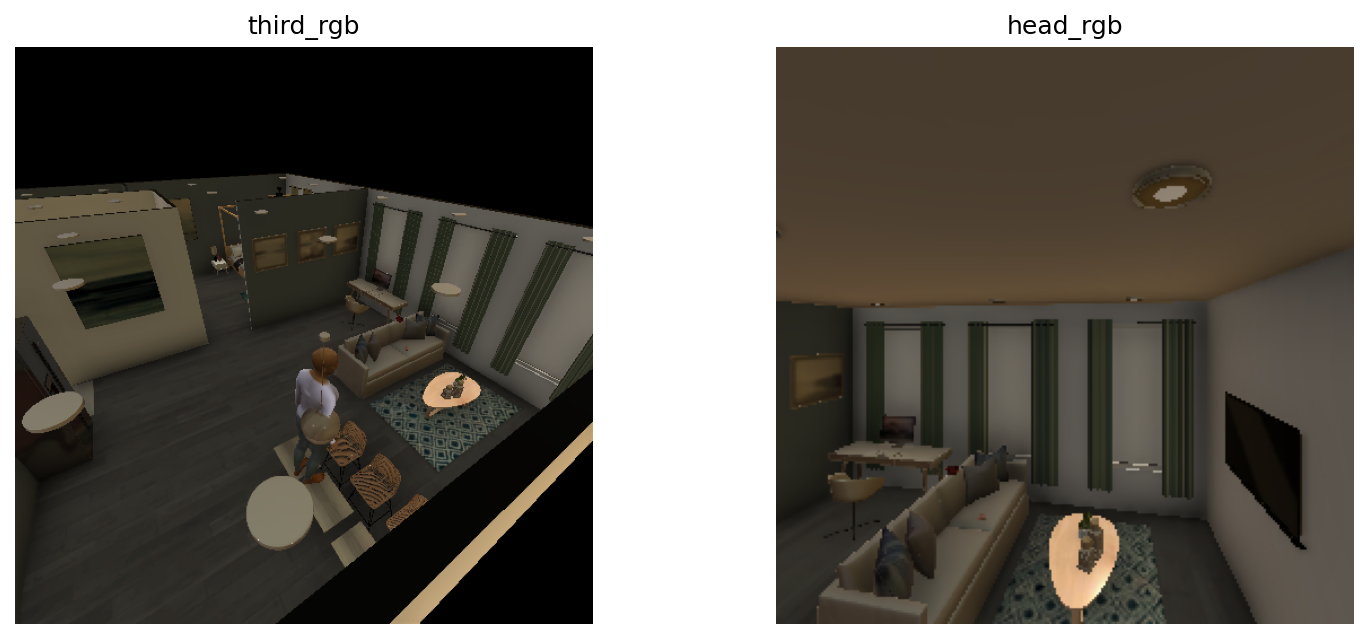

In [88]:
from IPython.display import Image, display
display(Image("/content/humanoid_moved.png"))


In [101]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from hab3_utils import *
import imageio

agent_dict = {"main_agent": default_humanoid_agent()}
action_dict = {"humanoid_joint_action": HumanoidJointActionConfig()}
env = init_rearrange_env(agent_dict, action_dict)
env.reset()

sim = env.sim
art_agent = sim.articulated_agent
sim.pathfinder.seed(42)
art_agent.base_pos = sim.pathfinder.get_random_navigable_point()

frames = []
num_iter = 100
pos_delta = mn.Vector3(0.02, 0, 0)
rot_delta = np.pi / (8 * num_iter)

for _ in range(num_iter):
    art_agent.base_pos = art_agent.base_pos + pos_delta
    art_agent.base_rot = art_agent.base_rot + rot_delta
    sim.step({})
    obs = sim.get_sensor_observations()
    frames.append(obs["third_rgb"][:, :, :3])

writer = imageio.get_writer("/content/humanoid_base_movement.mp4", fps=15)
for frame in frames:
    writer.append_data(frame)
writer.close()

print(f"Saved {len(frames)} frames")
env.close()
PY


Renderer: Tesla T4/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
hab3_utils.py ready
Saved 100 frames


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
2026-03-30 22:49:03,198 Initializing dataset RearrangeDataset-v0
2026-03-30 22:49:03,204 initializing sim RearrangeSim-v0
[22:49:04:374035]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hab3-hssd' : Lighting Layout Attributes 'data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
[22:49:04:374954]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `../hssd-hab_semantic_lexicon.json` does not exist.  Aborting load.
[22:49:04:375000]

In [102]:
from IPython.display import Video, display
display(Video("/content/humanoid_base_movement.mp4", embed=True, width=600))


In [95]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv

python -c "
from habitat.config.default_structured_configs import ThirdRGBSensorConfig
from omegaconf import OmegaConf
cfg = ThirdRGBSensorConfig()
print(OmegaConf.to_yaml(cfg))
"


type: HabitatSimRGBSensor
height: 512
width: 512
position:
- 0.0
- 1.25
- 0.0
orientation:
- 0.0
- 0.0
- 0.0
hfov: 90
sensor_subtype: PINHOLE
noise_model: None
noise_model_kwargs: {}
uuid: third_rgb



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [113]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from hab3_utils import *
import imageio

def random_rotation():
    random_dir = mn.Vector3(np.random.rand(3)).normalized()
    random_angle = random.random() * np.pi
    return mn.Quaternion.rotation(mn.Rad(random_angle), random_dir)

def custom_sample_humanoid():
    # Identity transforms — no base movement or rotation
    base_transform = mn.Matrix4()
    offset_transform = mn.Matrix4()  # no random rotation on body

    joints = []
    for _ in range(54):
        Q = random_rotation()
        joints = joints + list(Q.vector) + [float(Q.scalar)]

    offset_trans = list(np.asarray(offset_transform.transposed()).flatten())
    base_trans = list(np.asarray(base_transform.transposed()).flatten())
    return {"human_joints_trans": joints + offset_trans + base_trans}

agent_dict = {"main_agent": default_humanoid_agent()}
action_dict = {"humanoid_joint_action": HumanoidJointActionConfig()}
env = init_rearrange_env(agent_dict, action_dict)
env.reset()

sim = env.sim
sim.pathfinder.seed(42)
art_agent = sim.articulated_agent
art_agent.base_pos = sim.pathfinder.get_random_navigable_point()

frames = []
for _ in range(40):
    params = custom_sample_humanoid()
    action = {"action": "humanoid_joint_action", "action_args": params}
    obs = env.step(action)
    frames.append(obs["third_rgb"][:, :, :3])

writer = imageio.get_writer("/content/humanoid_random_joints.mp4", fps=5)
for frame in frames:
    writer.append_data(frame)
writer.close()
print(f"Saved {len(frames)} frames")
env.close()
PY


Renderer: Tesla T4/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
hab3_utils.py ready
Saved 40 frames


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
2026-03-30 23:01:34,512 Initializing dataset RearrangeDataset-v0
2026-03-30 23:01:34,518 initializing sim RearrangeSim-v0
[23:01:35:734828]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hab3-hssd' : Lighting Layout Attributes 'data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
[23:01:35:735813]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `../hssd-hab_semantic_lexicon.json` does not exist.  Aborting load.
[23:01:35:735850]

In [114]:
from IPython.display import Video, display
display(Video("/content/humanoid_random_joints.mp4", embed=True, width=600))


## Controllers

In [ ]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
pip install pybullet

cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from PIL import Image as PILImage
from hab3_utils import *
import imageio

from habitat.utils.humanoid_utils import MotionConverterSMPLX
PATH_TO_URDF = "data/humanoids/humanoid_data/female_2/female_2.urdf"
PATH_TO_MOTION_NPZ = "data/humanoids/humanoid_data/walk_motion/CMU_10_04_stageii.npz"
convert_helper = MotionConverterSMPLX(urdf_path=PATH_TO_URDF)
convert_helper.convert_motion_file(
    motion_path=PATH_TO_MOTION_NPZ,
    output_path=PATH_TO_MOTION_NPZ.replace(".npz", ""),
)
print("Motion file converted")

agent_dict = {"main_agent": default_humanoid_agent()}
action_dict = {"humanoid_joint_action": HumanoidJointActionConfig()}
env = init_rearrange_env(agent_dict, action_dict)
env.reset()

motion_path = "data/humanoids/humanoid_data/walk_motion/CMU_10_04_stageii.pkl"
humanoid_controller = HumanoidSeqPoseController(motion_path)
humanoid_controller.base_offset = mn.Vector3(humanoid_controller.base_offset)
humanoid_controller.reset(env.sim.articulated_agent.base_transformation)
humanoid_controller.apply_base_transformation(env.sim.articulated_agent.base_transformation)

frames = []
for _ in range(humanoid_controller.humanoid_motion.num_poses):
    humanoid_controller.calculate_pose()
    humanoid_controller.next_pose()
    new_pose = humanoid_controller.get_pose()
    action = {
        "action": "humanoid_joint_action",
        "action_args": {"human_joints_trans": new_pose}
    }
    obs = env.step(action)
    third = obs["third_rgb"][:,:,:3]
    head = obs["head_rgb"][:,:,:3]
    head_resized = np.array(PILImage.fromarray(head).resize((third.shape[1], third.shape[0])))
    frame = np.concatenate([third, head_resized], axis=1)
    frames.append(frame)

writer = imageio.get_writer("/content/humanoid_walk_mocap.mp4", fps=30)
for f in frames:
    writer.append_data(f)
writer.close()
print(f"Saved {len(frames)} frames — motion capture walk")
env.close()
PY


: 

In [120]:
from IPython.display import Video, display
display(Video("/content/humanoid_walk_mocap.mp4", embed=True, width=600))


In [117]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv

python -c "
import inspect
from habitat.articulated_agent_controllers.humanoid_seq_pose_controller import HumanoidSeqPoseController
src = inspect.getsource(HumanoidSeqPoseController.apply_base_transformation)
print(src)
"


    def apply_base_transformation(
        self, base_transformation: mn.Matrix4
    ) -> None:
        """Sets the current pose to the base transformation, making the rest of poses are relative to this one"""
        self.base_transform_offset = mn.Matrix4()
        self.base_transform_offset.translation = (
            -base_transformation.translation + self.base_offset
        )

        self.calculate_pose()



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Jan 29 2025 23:20:52
PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [118]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv

python -c "
import inspect
from habitat.articulated_agent_controllers.humanoid_seq_pose_controller import HumanoidSeqPoseController
src = inspect.getsource(HumanoidSeqPoseController.__init__)
for i, line in enumerate(src.split('\n')):
    if 'base_offset' in line:
        print(f'{i}: {line}')
"


4:         base_offset=(0, 0.9, 0),
6:         super().__init__(motion_fps, base_offset)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Jan 29 2025 23:20:52
PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring
